In [4]:
# y_hat = model(x)
# order = strategy(y_hat)
# execute(orders)

# regression model => BTCUSDT => future log return

In [5]:
import sys
print(sys.executable)

/home/jaden/Projects/Research/.venv/bin/python


In [6]:
# Data and analysis libraries
import polars as pl                         # Fast dataframes for financial data
import numpy as np                          # Numerical computing library
from datetime import datetime, timedelta    # Date and time operations
import random

# Machine learning libraries
import torch                                # Pytorch framework
import torch.nn as nn                       # Neural network modules
import torch.optim as optim                 # Optimization algorithms
import research                             # Model building and training utilities

# Visualization
import altair as alt                        # Interactive visualization library

# data sources
import binance                              # Binance market data utilities

In [7]:
research.set_seed(42)

In [8]:
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_cols(-1)  # Show all columns

polars.config.Config

In [9]:
# Trading pair symbol
sym = 'BTCUSDT'
# Historical data window in days (e.g., 6 months)
hist_data_window = 7 * 4 * 6
# time horizon of time series (time interval)
time_interval = '1h'
# max number of auto-regresive lags
max_lags = 4
# Forcase horizon in steps
forecast_horizon = 1
# Sharpe annualized rate (so it's independent of time frequency)
annualized_rate = research.sharpe_annualization_factor(time_interval, 365, 24)

In [10]:
print(binance.__file__)
print(hasattr(binance, "download_trades"))

/home/jaden/Projects/Research/binance.py
True


In [11]:
binance.download_trades(sym, hist_data_window)

In [12]:
ts = research.load_ohlc_timeseries(sym, time_interval)
ts

Loading BTCUSDT: 100%|██████████| 168/168 [01:05<00:00,  2.56file/s]


datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2026-01-26 00:00:00,86628.9,87150.8,86463.2,86808.4
2026-01-26 01:00:00,86808.5,87791.5,86772.9,87661.8
2026-01-26 02:00:00,87661.7,87922.0,87399.9,87514.8
2026-01-26 03:00:00,87514.7,87643.6,87028.5,87233.1
2026-01-26 04:00:00,87233.1,87908.4,87188.3,87700.0
…,…,…,…,…
2026-07-12 19:00:00,64124.7,64248.0,64114.9,64201.9
2026-07-12 20:00:00,64202.0,64227.4,64141.6,64168.5
2026-07-12 21:00:00,64168.5,64207.4,63856.3,63889.6


In [13]:
research.load_timeseries(sym, time_interval, pl.col('price').quantile(0.5).alias('price_median'))

Loading BTCUSDT: 100%|██████████| 168/168 [01:12<00:00,  2.32file/s]


datetime,price_median
datetime[μs],f64
2026-01-26 00:00:00,86828.9
2026-01-26 01:00:00,87538.0
2026-01-26 02:00:00,87605.4
2026-01-26 03:00:00,87358.7
2026-01-26 04:00:00,87719.9
…,…
2026-07-12 19:00:00,64165.0
2026-07-12 20:00:00,64173.2
2026-07-12 21:00:00,64011.8


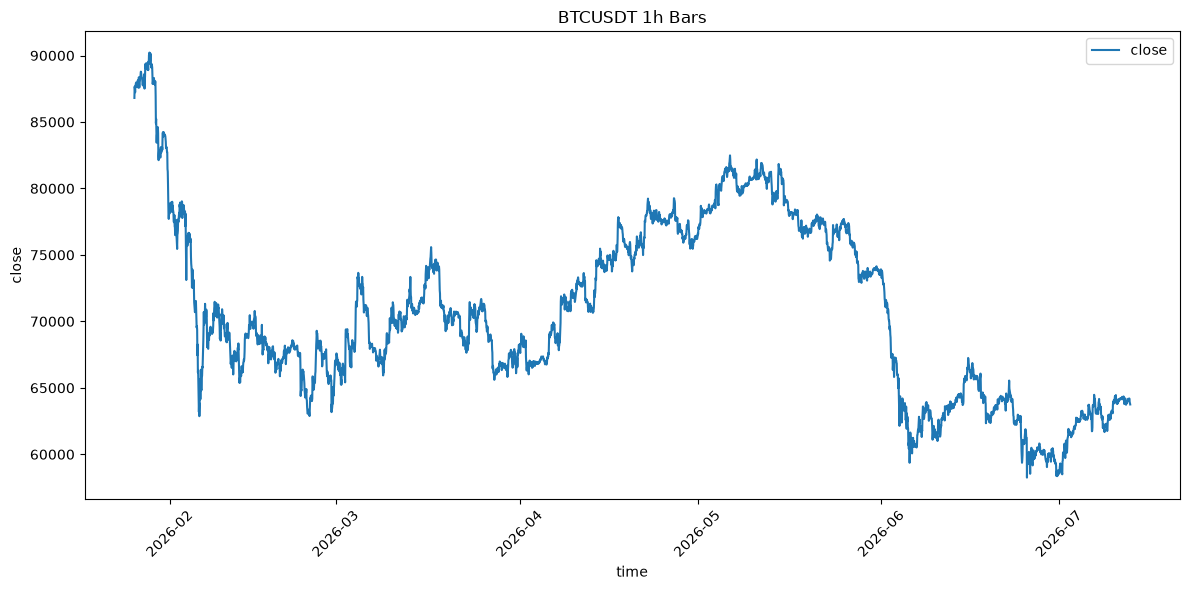

In [14]:
research.plot_static_timeseries(ts, sym, 'close', time_interval)

In [15]:
alt.data_transformers.enable("vegafusion")
research.plot_dyn_timeseries(ts, sym, 'close', time_interval)

alt.Chart(...)

## Feature Engineering

In [16]:
price_time_series = pl.DataFrame({'price':[100.0,120.0,100.0]})
research.plot_column(price_time_series, 'price')

alt.Chart(...)

In [17]:
price_time_series.with_columns(
    pl.col('price').diff().alias('delta'),
    ((pl.col('price')-pl.col('price').shift())/pl.col('price').shift()).alias('return'),
    (pl.col('price')/pl.col('price').shift()).log().alias('log_return'),
)

price,delta,return,log_return
f64,f64,f64,f64
100.0,null,null,null
120.0,20.0,0.2,0.182322
100.0,-20.0,-0.166667,-0.182322


### Create target and lagged features

In [18]:
ts = ts.with_columns((pl.col('close')/pl.col('close').shift(forecast_horizon)).log().alias('close_log_return'))
ts

datetime,open,high,low,close,close_log_return
datetime[μs],f64,f64,f64,f64,f64
2026-01-26 00:00:00,86628.9,87150.8,86463.2,86808.4,null
2026-01-26 01:00:00,86808.5,87791.5,86772.9,87661.8,0.009783
2026-01-26 02:00:00,87661.7,87922.0,87399.9,87514.8,-0.001678
2026-01-26 03:00:00,87514.7,87643.6,87028.5,87233.1,-0.003224
2026-01-26 04:00:00,87233.1,87908.4,87188.3,87700.0,0.005338
…,…,…,…,…,…
2026-07-12 19:00:00,64124.7,64248.0,64114.9,64201.9,0.001205
2026-07-12 20:00:00,64202.0,64227.4,64141.6,64168.5,-0.00052
2026-07-12 21:00:00,64168.5,64207.4,63856.3,63889.6,-0.004356


In [19]:
target = 'close_log_return'
lr = pl.col(target)
ts = ts.with_columns(
    lr.shift(forecast_horizon * 1).alias(f'{target}_lag_1'),
    lr.shift(forecast_horizon * 2).alias(f'{target}_lag_2'),
    lr.shift(forecast_horizon * 3).alias(f'{target}_lag_3'),
    lr.shift(forecast_horizon * 4).alias(f'{target}_lag_4'),
)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-01-26 00:00:00,86628.9,87150.8,86463.2,86808.4,null,null,null,null,null
2026-01-26 01:00:00,86808.5,87791.5,86772.9,87661.8,0.009783,null,null,null,null
2026-01-26 02:00:00,87661.7,87922.0,87399.9,87514.8,-0.001678,0.009783,null,null,null
2026-01-26 03:00:00,87514.7,87643.6,87028.5,87233.1,-0.003224,-0.001678,0.009783,null,null
2026-01-26 04:00:00,87233.1,87908.4,87188.3,87700.0,0.005338,-0.003224,-0.001678,0.009783,null
…,…,…,…,…,…,…,…,…,…
2026-07-12 19:00:00,64124.7,64248.0,64114.9,64201.9,0.001205,0.001159,-0.001505,-0.000048,-0.000391
2026-07-12 20:00:00,64202.0,64227.4,64141.6,64168.5,-0.00052,0.001205,0.001159,-0.001505,-0.000048
2026-07-12 21:00:00,64168.5,64207.4,63856.3,63889.6,-0.004356,-0.00052,0.001205,0.001159,-0.001505


In [20]:
ts = research.add_lags(ts, target, max_lags, forecast_horizon)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-01-26 00:00:00,86628.9,87150.8,86463.2,86808.4,null,null,null,null,null
2026-01-26 01:00:00,86808.5,87791.5,86772.9,87661.8,0.009783,null,null,null,null
2026-01-26 02:00:00,87661.7,87922.0,87399.9,87514.8,-0.001678,0.009783,null,null,null
2026-01-26 03:00:00,87514.7,87643.6,87028.5,87233.1,-0.003224,-0.001678,0.009783,null,null
2026-01-26 04:00:00,87233.1,87908.4,87188.3,87700.0,0.005338,-0.003224,-0.001678,0.009783,null
…,…,…,…,…,…,…,…,…,…
2026-07-12 19:00:00,64124.7,64248.0,64114.9,64201.9,0.001205,0.001159,-0.001505,-0.000048,-0.000391
2026-07-12 20:00:00,64202.0,64227.4,64141.6,64168.5,-0.00052,0.001205,0.001159,-0.001505,-0.000048
2026-07-12 21:00:00,64168.5,64207.4,63856.3,63889.6,-0.004356,-0.00052,0.001205,0.001159,-0.001505


In [22]:
ts = ts.drop_nulls()

In [23]:
research.plot_distribution(ts, target, no_bins=100)

alt.Chart(...)

In [24]:
research.plot_distribution(ts, 'close', no_bins=100)

alt.Chart(...)

### Build Model

In [25]:
class LinearModel(nn.Module):
    def __init__(self, input_features):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return self.linear(x)

### Complexity of the model

In [26]:
input_features = 1

linear_model = LinearModel(input_features)

research.print_model_info(linear_model, "Linear Model")
research.total_model_params(linear_model)


Linear Model

Architecture:
  LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      2
  Trainable parameters:  2



2

In [ ]:
# y = w * x + b